In [1]:
from herbie import Herbie

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import metpy.calc as mpcalc
import numpy as np
import pandas as pd

from herbie import paint
from herbie.toolbox import EasyMap, pc
from scipy.interpolate import griddata
import scipy.ndimage
from PIL import Image

In [2]:
H = Herbie("2026-3-18-00", model="ifs", product="oper", fxx=24)

H.grib, H.idx

✅ Found ┊ model=ifs ┊ product=oper ┊ 2026-Mar-18 00:00 UTC F24 ┊ GRIB2 @ google ┊ IDX @ local


('https://storage.googleapis.com/ecmwf-open-data/20260318/00z/ifs/0p25/oper/20260318000000-24h-oper-fc.grib2',
 WindowsPath('C:/Users/andyzhang/data/ifs/20260318/20260318000000-24h-oper-fc.index'))

In [3]:
# ========== 讀取850百帕風場資料 ==========
# 讀取850百帕 u 風分量 (東西向)
ds_2 = H.xarray(":u:850")
# 讀取850百帕 v 風分量 (南北向)
ds_3 = H.xarray(":v:850")
# 計算850百帕風速 (ds_4 就是這裡定義的)
ds_4 = mpcalc.wind_speed(ds_2.u, ds_3.v)

In [4]:
ds_2 = ds_2.sel(latitude=slice(30, 15,4), longitude=slice(105, 125,2))
ds_3 = ds_3.sel(latitude=slice(30, 15,4), longitude=slice(105, 125,2))
ds_4 = ds_4.sel(latitude=slice(30, 15), longitude=slice(105, 125))

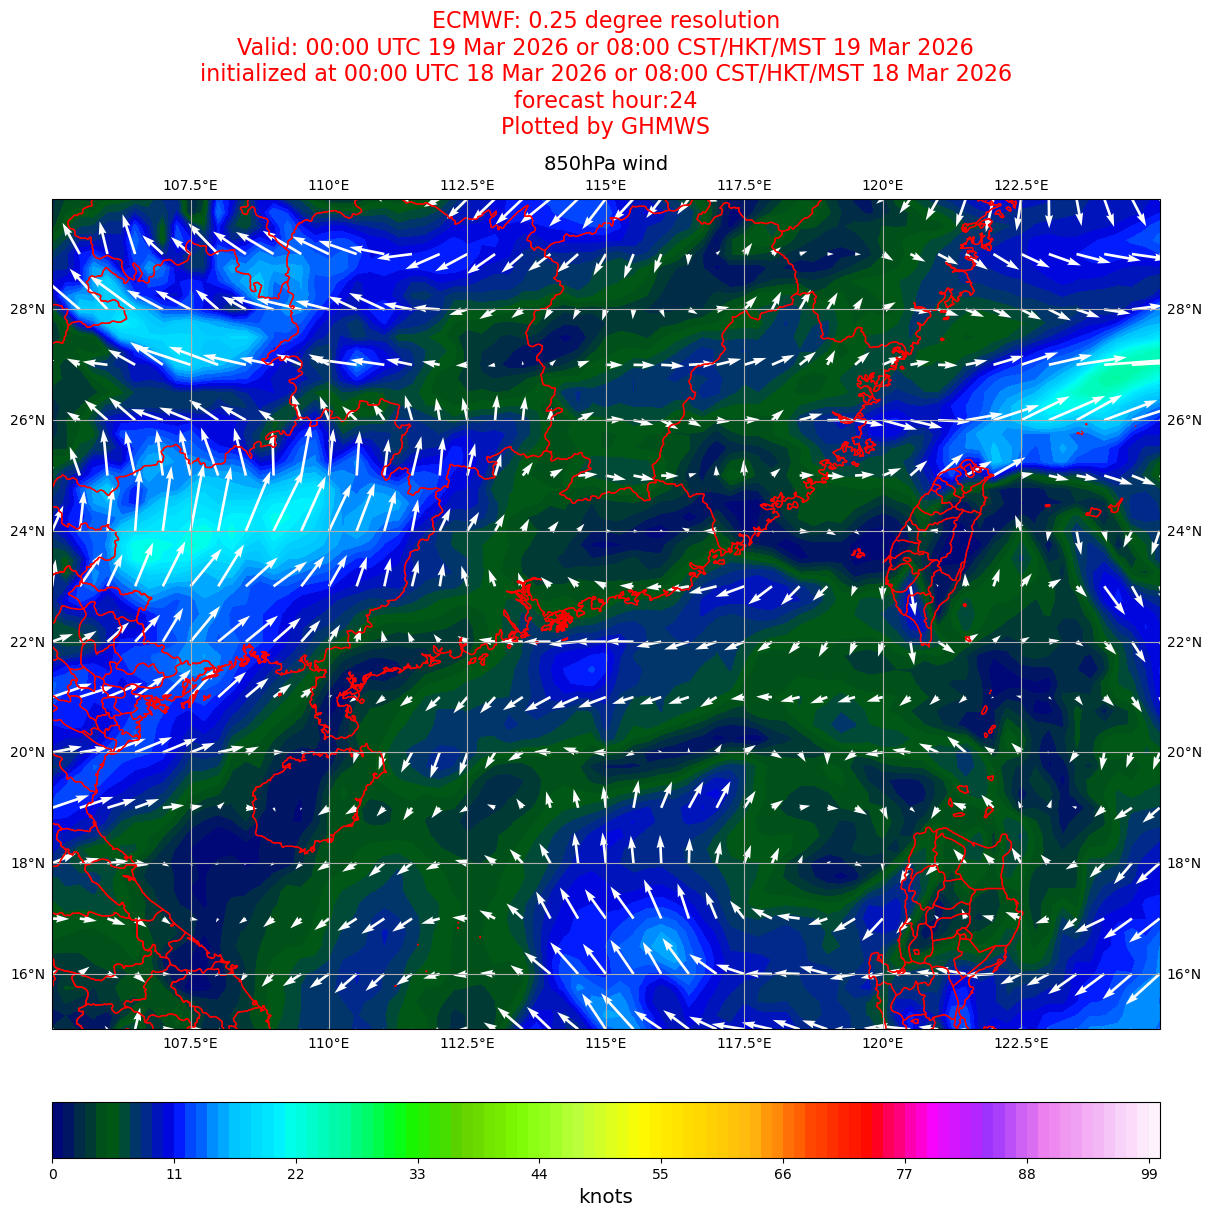

In [5]:
def plot_background(ax):
    ax.set_extent([105,125,15,30])
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=1, edgecolor='red')
    ax.add_feature(cfeature.STATES, linewidth=1, edgecolor='red')
    ax.add_feature(cfeature.BORDERS, linewidth=1, edgecolor='red')
    gl = ax.gridlines(draw_labels=True)
    gl.xlabels_top = False
    gl.ylabels_left = False
    return ax

fig, ax = plt.subplots(figsize=(12, 12), constrained_layout=True,
                       subplot_kw={'projection': ccrs.PlateCarree()})
plot_background(ax)

# 繪製風速填色+風矢
p = ax.contourf(
    ds_4.longitude,
    ds_4.latitude,
    ds_4*3.6/1.852,
    transform=pc,
    cmap="gist_ncar",
    levels=np.arange(0,101,1)
)
ax.quiver(ds_2.longitude, ds_2.latitude,
          ds_2.u*3.6/1.852, ds_3.v*3.6/1.852,
          color='w', transform=pc)

ax.set_title(f'850hPa wind', fontsize=14)
cb1 = fig.colorbar(p, ax=ax, orientation='horizontal')
cb1.set_label(f'knots', size='x-large')

valid_UTC = ds_2.valid_time.dt.strftime('%H:%M UTC %d %b %Y').item()
valid_CST = (pd.to_datetime(ds_2.valid_time.values) + pd.Timedelta(hours=8)).strftime('%H:%M CST/HKT/MST %d %b %Y')
init_UTC = ds_2.time.dt.strftime('%H:%M UTC %d %b %Y').item()
init_CST = (pd.to_datetime(ds_2.time.values) + pd.Timedelta(hours=8)).strftime('%H:%M CST/HKT/MST %d %b %Y')

fig.suptitle(
    f"ECMWF: 0.25 degree resolution\nValid: {valid_UTC} or {valid_CST}\ninitialized at {init_UTC} or {init_CST}\nforecast hour:{H.fxx}\nPlotted by GHMWS",
    color='red', fontsize=16
)

plt.show()